# Assignment 7 — Transfer Learning


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


## 1. Load and preprocess MNIST
MNIST is grayscale (28×28), while ImageNet-pretrained networks expect 3-channel images. We convert grayscale to RGB and resize to 32×32 for the Keras models. The notebook uses a smaller subset to keep training practical in Colab.

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

IMG_SIZE = 32
TRAIN_SAMPLES = 10000
TEST_SAMPLES = 2000

x_train = np.repeat(x_train[..., np.newaxis], 3, axis=-1)
x_test = np.repeat(x_test[..., np.newaxis], 3, axis=-1)

x_train = tf.image.resize(x_train, (IMG_SIZE, IMG_SIZE)).numpy().astype('float32') / 255.0
x_test = tf.image.resize(x_test, (IMG_SIZE, IMG_SIZE)).numpy().astype('float32') / 255.0

x_train_small = x_train[:TRAIN_SAMPLES]
y_train_small = y_train[:TRAIN_SAMPLES]
x_test_small = x_test[:TEST_SAMPLES]
y_test_small = y_test[:TEST_SAMPLES]

print('Training:', x_train_small.shape, y_train_small.shape)
print('Testing :', x_test_small.shape, y_test_small.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training: (10000, 32, 32, 3) (10000,)
Testing : (2000, 32, 32, 3) (2000,)


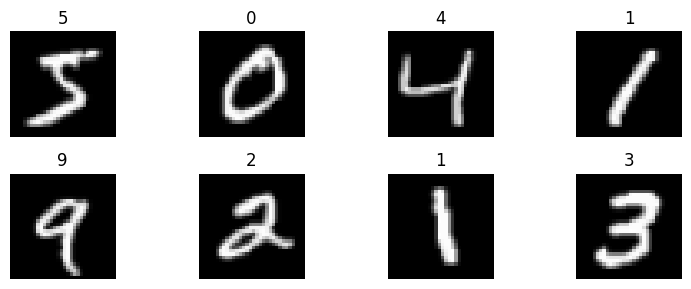

In [ ]:
plt.figure(figsize=(8,3))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_train_small[i])
    plt.title(str(y_train_small[i]))
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Build the three TensorFlow/Keras transfer-learning models


In [ ]:
def build_vgg16():
    base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    base.trainable = False
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

def build_resnet50():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    base.trainable = False
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

def build_efficientnetb0():
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    base.trainable = False
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

def compile_model(model):
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

## 3. Train and evaluate VGG16, ResNet50 and EfficientNetB0

In [ ]:
EPOCHS = 3
BATCH_SIZE = 64
results = []
histories = {}

def train_keras_model(name, builder):
    print('\n' + '='*60)
    print(name)
    model = compile_model(builder())
    start = time.time()
    history = model.fit(
        x_train_small, y_train_small,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        verbose=1
    )
    train_time = time.time() - start
    loss, acc = model.evaluate(x_test_small, y_test_small, verbose=0)
    results.append({'Model': name, 'Test Accuracy': acc, 'Test Loss': loss, 'Training Time (s)': train_time})
    histories[name] = history
    return model

vgg16_model = train_keras_model('VGG16', build_vgg16)
resnet50_model = train_keras_model('ResNet50', build_resnet50)
efficientnet_model = train_keras_model('EfficientNetB0', build_efficientnetb0)


VGG16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 118s 831ms/step - accuracy: 0.5784 - loss: 1.3143 - val_accuracy: 0.8360 - val_loss: 0.6714
Epoch 2/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 143s 837ms/step - accuracy: 0.7922 - loss: 0.6943 - val_accuracy: 0.8840 - val_loss: 0.4420
Epoch 3/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 132s 759ms/step - accuracy: 0.8458 - loss: 0.5217 - val_accuracy: 0.9070 - val_loss: 0.3367

ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 48s 281ms/step - accuracy: 0.4127 - loss: 1.7506 - val_accuracy: 0.7110 - val_loss: 1.1491
Epoch 2/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 38s 260ms/step - accuracy: 0.6032 - loss: 1.2140 - val_accuracy: 0.8060 - val_loss: 0.7926
Epoch 3/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 36s 253ms/step - accuracy: 0.6791 - loss: 0.9905 - val_accuracy: 0.8020 - val_loss: 0.6589

EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
141/141 ━━━━━━━━━━━━━

## 4. Pretrained AlexNet
AlexNet is loaded from `torchvision` because TensorFlow/Keras does not ship an official ImageNet-pretrained AlexNet. Its convolutional feature extractor is frozen and only the classifier is adapted for 10 MNIST classes.

In [ ]:
# Install/upgrade torchvision only if needed in Colab
# !pip -q install torch torchvision

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import alexnet, AlexNet_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch device:', device)

# Convert 32x32 tensors to a PyTorch dataset. AlexNet's pretrained weights
# expect ImageNet-sized input, so images are resized to 224x224 in the model.
xtr = torch.tensor(x_train_small).permute(0,3,1,2)
ytr = torch.tensor(y_train_small, dtype=torch.long)
xte = torch.tensor(x_test_small).permute(0,3,1,2)
yte = torch.tensor(y_test_small, dtype=torch.long)

train_loader = DataLoader(TensorDataset(xtr, ytr), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(xte, yte), batch_size=64, shuffle=False)

weights = AlexNet_Weights.DEFAULT
alexnet_model = alexnet(weights=weights)
for param in alexnet_model.features.parameters():
    param.requires_grad = False
alexnet_model.classifier[6] = nn.Linear(alexnet_model.classifier[6].in_features, 10)
alexnet_model = alexnet_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(alexnet_model.classifier.parameters(), lr=1e-3)

alex_train_acc = []
alex_val_acc = []
start = time.time()

for epoch in range(EPOCHS):
    alexnet_model.train()
    correct = total = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        xb = torch.nn.functional.interpolate(xb, size=(224,224), mode='bilinear', align_corners=False)
        optimizer.zero_grad()
        out = alexnet_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        correct += (out.argmax(1) == yb).sum().item()
        total += yb.size(0)
    train_acc = correct / total

    alexnet_model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            xb = torch.nn.functional.interpolate(xb, size=(224,224), mode='bilinear', align_corners=False)
            out = alexnet_model(xb)
            correct += (out.argmax(1) == yb).sum().item()
            total += yb.size(0)
    val_acc = correct / total
    alex_train_acc.append(train_acc)
    alex_val_acc.append(val_acc)
    print(f'Epoch {epoch+1}/{EPOCHS} - train_accuracy: {train_acc:.4f} - test_accuracy: {val_acc:.4f}')

alexnet_time = time.time() - start
results.append({'Model':'AlexNet', 'Test Accuracy':alex_val_acc[-1], 'Test Loss':np.nan, 'Training Time (s)':alexnet_time})

## 5. Compare model performance

In [ ]:
results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
results_df

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['Test Accuracy'])
plt.ylim(0, 1.0)
plt.ylabel('Test Accuracy')
plt.xlabel('Model')
plt.title('Transfer Learning Model Comparison')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
# Training curves for the three Keras models
plt.figure(figsize=(9,5))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], marker='o', label=name)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9,5))
plt.plot(range(1, EPOCHS+1), alex_train_acc, marker='o', label='AlexNet train')
plt.plot(range(1, EPOCHS+1), alex_val_acc, marker='o', label='AlexNet test')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('AlexNet Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 6. Conclusion
The final ranking should be taken directly from `results_df` after running the notebook. The best model is the one with the highest test accuracy, while training time indicates computational cost. Because MNIST is very different from ImageNet, the comparison demonstrates transfer learning but does not necessarily reflect which architecture is best for natural-image classification. AlexNet uses a pretrained ImageNet feature extractor through torchvision; VGG16, ResNet50 and EfficientNetB0 use their Keras ImageNet-pretrained backbones.